# Elastic wave spatial convergence tutorial

This tutorial was prepared by Alexandre Olender: olender@usp.br

This tutorial demonstrates how to investigate spatial convergence for isotropic elastic wave propagation in Spiro.


We will:
1. Introduce the concept of spatial convergence;
2. Compare the numerical solution with an analytical solution;
3. Investigate spatial convergence by refining the mesh;
4. Calculate the observed spatial convergence rate.

Temporal convergence is discussed briefly, but is not investigated in this tutorial.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import spyro
from scipy.signal import correlate

from spyro.tools.error_measure import MeasureError

## 1. What is spatial convergence?

A numerical solution should approach the exact solution as the spatial discretization is refined.

Let $E$ denote the numerical error and $h$ denote a characteristic measure of the mesh size, such as the element edge length or circumcircle radius. If a numerical method has spatial convergence order $p$ (not necessarily the polynomial order of the FEM function space), we expect

$$
\frac{|E(h)|}{h^p} \approx C.
$$

where $C$ is approximately constant. The convergence order $p$ describes how quickly the numerical error decreases as the mesh is refined.

In wave propagation simulations, we typically have two discretization parameters:
* Temporal discretization: the time step $\textit{d}t$;
* Spatial discretization: the mesh size $h$.

Therefore, the total numerical error can contain contributions from both temporal and spatial discretization. In this tutorial, we focus on spatial convergence. We therefore keep $\textit{d}t$ sufficiently small while progressively reducing the mesh size $h$.

We use the same homogeneous isotropic medium and acquisition geometry as in the temporal convergence tutorial.

## Choice of simulation time and boundary conditions

To keep this tutorial computationally affordable, we use a periodic computational domain rather than increasing the domain size. The `final_time` is chosen so that the waves do not reach the periodic boundaries.

This is important for the convergence analysis because the analytical solution represents wave propagation in an unbounded homogeneous medium. If `final_time` is increased sufficiently, waves may travel across the periodic boundaries and re-enter the computational domain, contaminating the comparison with the analytical solution. Consequently, increasing `final_time` without consideration can cause the observed convergence rate to fall.

In [2]:
vp = 1.5
vs = 1.0
rho = 0.1

source_z = -2.0
receiver_z = -2.5

source_locations = [(source_z, -source_z)]
receiver_locations = [(receiver_z, -receiver_z)]

final_time = 1.2
dt = 2.0e-4
periodic_mesh = True

In [3]:
dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 4.0,
        "length_x": 4.0,
        "mesh_type": "firedrake_mesh",
        "periodic": periodic_mesh,
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": source_locations,
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": final_time,
        "dt": dt,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}
dictionary["synthetic_data"] = {
    "type": "object",
    "density": rho,
    "p_wave_velocity": vp,
    "s_wave_velocity": vs,
    "real_velocity_file": None,
}
wave = spyro.IsotropicWave(dictionary)

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters


/workspaces/fwi_examples/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


We will begin by adding a wrapper to Spiro's 2D analytical solution method, so we can get an analytical solution result measured at that timestep.

In [4]:
offsets = np.array(source_locations[0]) - np.array(receiver_locations[0])

def get_analytical_solution(dt):
    return spyro.utils.analytical_solution_elastic(
        source_type="force_source",
        offsets=offsets,
        p_wave_velocity=vp,
        s_wave_velocity=vs,
        density=rho,
        amplitude=1.0,
        frequency=5.0,
        time_delay=0.2,
        final_time=final_time,
        dt=dt,
        force_direction=1,
        dimension=2,
    )

We will create a small function so we can get a result by varying the element edge length.

In [5]:
def get_numerical_result(wave, h):
    wave.set_mesh(
        input_mesh_parameters={
            "edge_length": h,
            "periodic": periodic_mesh,
        }
    )
    wave.forward_solve()
    return wave.forward_solution_receivers

In [6]:
mesh_sizes = np.array([
    0.15,
    0.10,
    0.075,
    0.05,
])

We will calculate the normalized L2 error between the receiver result and the analytical solution for that offset.

In [7]:
errors = []

for h in mesh_sizes:
    numerical_result = get_numerical_result(wave, h)
    analytical_result = get_analytical_solution(dt)

    error = MeasureError.calculate_normalized_L2_error(
        numerical_result[:, 0, 0],
        analytical_result[0],
    )

    errors.append(error)

errors = np.array(errors)
for h, error in zip(mesh_sizes, errors):
    print(f"h = {h:.3e}  |  error = {error:.6e}")

Creating firedrake_mesh type mesh.
Mesh Created with 729 Nodes and 729 Area Elements

Solving Forward Problem
Simulation time is:        0.0 seconds
Simulation time is:       0.02 seconds


/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:       0.04 seconds
Simulation time is:       0.06 seconds
Simulation time is:       0.08 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.12 seconds
Simulation time is:       0.14 seconds
Simulation time is:       0.16 seconds
Simulation time is:       0.18 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.22 seconds
Simulation time is:       0.24 seconds
Simulation time is:       0.26 seconds
Simulation time is:       0.28 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.32 seconds
Simulation time is:       0.34 seconds
Simulation time is:       0.36 seconds
Simulation time is:       0.38 seconds
Simulation time is:        0.4 seconds
Simulation time is:       0.42 seconds
Simulation time is:       0.44 seconds
Simulation time is:       0.46 seconds
Simulation time is:       0.48 seconds
Simulation time is:        0.5 seconds
Simulation time is:       0.52 seconds
Simulation time is:      

/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:       0.02 seconds
Simulation time is:       0.04 seconds
Simulation time is:       0.06 seconds
Simulation time is:       0.08 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.12 seconds
Simulation time is:       0.14 seconds
Simulation time is:       0.16 seconds
Simulation time is:       0.18 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.22 seconds
Simulation time is:       0.24 seconds
Simulation time is:       0.26 seconds
Simulation time is:       0.28 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.32 seconds
Simulation time is:       0.34 seconds
Simulation time is:       0.36 seconds
Simulation time is:       0.38 seconds
Simulation time is:        0.4 seconds
Simulation time is:       0.42 seconds
Simulation time is:       0.44 seconds
Simulation time is:       0.46 seconds
Simulation time is:       0.48 seconds
Simulation time is:        0.5 seconds
Simulation time is:      

/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:       0.02 seconds
Simulation time is:       0.04 seconds
Simulation time is:       0.06 seconds
Simulation time is:       0.08 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.12 seconds
Simulation time is:       0.14 seconds
Simulation time is:       0.16 seconds
Simulation time is:       0.18 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.22 seconds
Simulation time is:       0.24 seconds
Simulation time is:       0.26 seconds
Simulation time is:       0.28 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.32 seconds
Simulation time is:       0.34 seconds
Simulation time is:       0.36 seconds
Simulation time is:       0.38 seconds
Simulation time is:        0.4 seconds
Simulation time is:       0.42 seconds
Simulation time is:       0.44 seconds
Simulation time is:       0.46 seconds
Simulation time is:       0.48 seconds
Simulation time is:        0.5 seconds
Simulation time is:      

In [8]:
log_h = np.log(mesh_sizes)
log_errors = np.log(errors)

p, intercept = np.polyfit(log_h, log_errors, 1)

print(f"Observed spatial convergence order: {p:.3f}")


Observed spatial convergence order: 6.471


We calculate the normalized L2 error between the numerical and analytical solutions at the receiver. Using receiver data avoids evaluating the analytical solution over the entire computational domain, which would be considerably more expensive.

Since the error is measured at a receiver rather than in the L2 norm of the complete field, the observed convergence rate can be more sensitive to numerical dispersion and other local numerical effects. Therefore, it may differ from the theoretical $O(h^{(p+1)})$ rate expected.

In [9]:
p_theory = 5

theory = errors[0] * (mesh_sizes / mesh_sizes[0]) ** p_theory

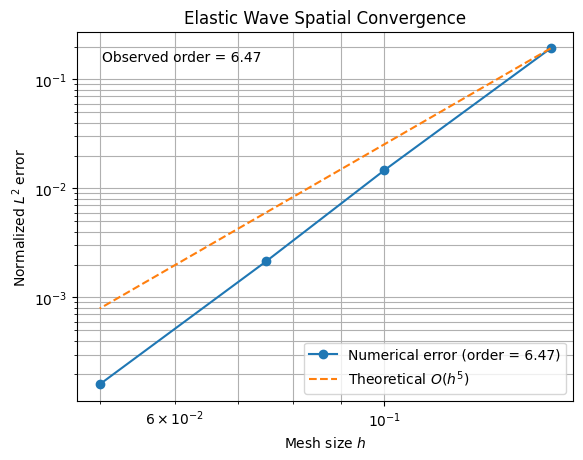

In [10]:
fig, ax = plt.subplots()

ax.loglog(
mesh_sizes,
errors,
"o-",
label=f"Numerical error (order = {p:.2f})",
)

ax.loglog(
mesh_sizes,
theory,
"--",
label=fr"Theoretical $O(h^{{{p_theory}}})$",
)

ax.set_xlabel(r"Mesh size $h$")
ax.set_ylabel(r"Normalized $L^2$ error")
ax.set_title("Elastic Wave Spatial Convergence")

ax.grid(True, which="both")
ax.legend()

ax.text(
0.05,
0.95,
f"Observed order = {p:.2f}",
transform=ax.transAxes,
verticalalignment="top",
)

plt.show()